# Lazy vs rich training dynamics

Left: `lazy_balance.json` (α = 32). Right: `rich_balance.json` (α = 1). Rows: real vs null frustration, loss, distance.
Formatted for a NeurIPS figure (5.5 in text width, Times, 8 pt). Writes `lazy_rich_balance.pdf` (use this in LaTeX) and `lazy_rich_balance.png` (preview).

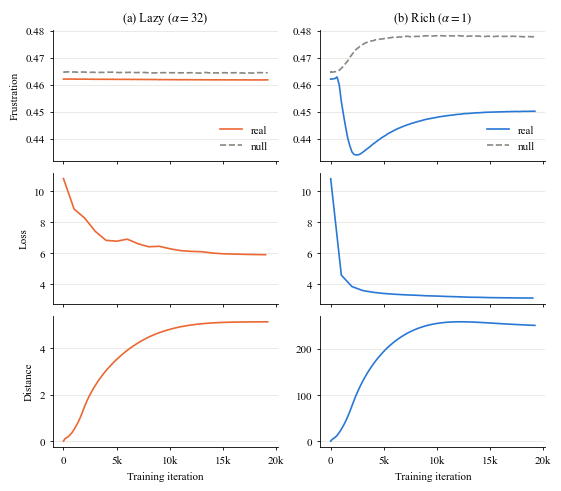

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# NeurIPS: 5.5 in text width, Times body font, embedded TrueType (no Type 3) fonts in the PDF.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

RUNS = [  # (file, panel title, line colour)
    ("lazy_balance.json", "Lazy", "#eb6834"),
    ("rich_balance.json", "Rich", "#2a78d6"),
]
NULL_COLOR = "#898781"
OUT = Path("lazy_rich_balance")

fig, axes = plt.subplots(3, 2, figsize=(5.5, 4.8), sharex=True, constrained_layout=True)
for col, (fname, name, color) in enumerate(RUNS):
    d = json.load(open(fname))
    it = np.array(d["epoch"])  # training iterations (max_iters = 19200)
    ax_frust, ax_loss, ax_dist = axes[:, col]

    ax_frust.plot(it, d["r_frust"], color=color, label="real")
    ax_frust.plot(it, [v[0] for v in d["n_frust"]], color=NULL_COLOR, ls="--", label="null")
    ax_frust.legend(loc="lower right", frameon=False)
    ax_frust.set_title(rf"({'ab'[col]}) {name} ($\alpha = {d['train_config']['alpha']:g}$)")

    # loss is only re-evaluated every eval_interval iterations; snapshots in between repeat the stale value
    evaluated = it % d["train_config"]["eval_interval"] == 0
    ax_loss.plot(it[evaluated], np.array(d["loss"])[evaluated], color=color)

    ax_dist.plot(it, d["distance"], color=color)
    ax_dist.set_xlabel("Training iteration")
    ax_dist.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:g}k" if v else "0"))

# same y scale for frustration and loss; distance differs ~50x between runs, so each panel keeps its own
axes[0, 0].sharey(axes[0, 1])
axes[1, 0].sharey(axes[1, 1])
axes[0, 0].set_ylabel("Frustration")
axes[1, 0].set_ylabel("Loss")
axes[2, 0].set_ylabel("Distance")
for ax in axes.flat:
    ax.grid(axis="y", color="#e1e0d9", lw=0.5)

fig.savefig(OUT.with_suffix(".pdf"))
fig.savefig(OUT.with_suffix(".png"), dpi=300)
